In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import components.broadcast_components.WZ_models.wz_quant_ANN
import components.broadcast_components.WZ_models.wz_quant_RNN
import components.other_utilities.brent_wz_models
import utilities
import importlib

# ----------------------------------------------------------------
torch.set_float32_matmul_precision('medium')
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
import warnings
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX` has been removed")
warnings.filterwarnings("ignore", message="You defined a `validation_step` but have no `val_dataloader`")
warnings.filterwarnings("ignore", message="Consider setting `persistent_workers=True` in 'train_dataloader'")
warnings.filterwarnings("ignore", message="The 'val_dataloader' does not have")

In [2]:
# import gzip
# import pickle
# y=[]
# side_info_data = []
# for i in range(3):
#     path_to_grad = f'../exp_data/single_round_worker_sgd_resnet_raw_grads/corr_res_round_0,epoch_0,batch_{i}.pkl.gz'
#     with gzip.open(path_to_grad, 'rb') as f:
#         y += [pickle.load(f).numpy().astype(np.float32)]
# y = np.sum(y, axis=0)
#
# y+=np.random.normal(0, np.sqrt(2e-6), len(y), ).astype(np.float32)

In [3]:
import random
random.seed(10)
torch.manual_seed(10)
np.random.seed(10)

temp = np.random.normal(0, np.sqrt(1), 2_000_000, ).astype(np.float32)
y = temp + np.random.normal(0, np.sqrt(0.01), 2_000_000, ).astype(np.float32)
side_info_data = [temp]

In [4]:
importlib.reload(utilities)
y, side_info_data = utilities.prep_data(y, side_info_data, normalize=False)
side_info_variance, noise_variance = utilities.get_data_var(y, side_info_data)

In [5]:
plt.figure(figsize=(12, 2))
plt.hist(y, density=True, alpha=0.5, bins=500)
if len(side_info_data):
    plt.hist(side_info_data[0], 500, density=True, alpha=0.2)
# plt.ylim(0,5)
# plt.xlim(-2,2)
plt.show()

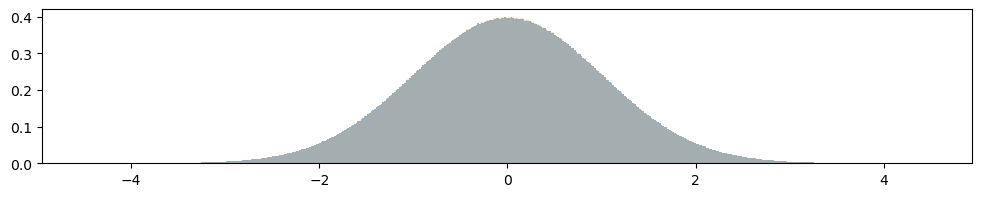

In [6]:
importlib.reload(components.broadcast_components.WZ_models.wz_quant_ANN)
importlib.reload(components.broadcast_components.WZ_models.wz_quant_RNN)
importlib.reload(components.other_utilities.brent_wz_models)
from components.broadcast_components.WZ_models.wz_quant_ANN import WZQuantizer
from components.broadcast_components.WZ_models.wz_quant_RNN import PL_EncoderDecoder_RNN
from components.broadcast_components.WZ_models.wz_quant_RNN import PL_EncoderDecoder_ANN

# seed set
import random
random.seed(10)
torch.manual_seed(10)
np.random.seed(10)

wz_model = PL_EncoderDecoder_ANN(inp_dim=1, side_info_size=1, bin_count=4, tau=4, reconst_ld=1000, lr=2e-3, ).to(torch.float32)

# wz_model.load_state_dict(torch.load(r'D:\User\App Files\Projects\VUB-ACS-25_Thesis\data\basicRNN_3plane_4bins_state.pt', map_location='cpu'))
# wz_model.load_state_dict(torch.load('chkpnt.pt', map_location='cpu'))
# wz_model.coding_model.load_state_dict(torch.load('checkpoint.pth', map_location='cpu', weights_only=False)['model_state_dict'])

wz_quantizer = WZQuantizer(wz_model, train_sample_size=200_000, count_side_info_data=1, enable_progress_bar=True)

wz_quantizer.train_model(y, side_info_data, epoch=60, batch_size=10_000)

# torch.save(wz_model.state_dict(), 'chkpnt.pt')

# torch.save(wz_model.state_dict(), r'D:\User\App Files\Projects\VUB-ACS-25_Thesis\data\basicRNN_3plane_4bins_state.pt')

In [20]:
importlib.reload(utilities)
mse, mspe, real_bit_rate, prior_bit_rate, softcodes_bit_rate, alt_real_bits = utilities.get_metrics(y, side_info_data, wz_quantizer, )
f'{mse=:0.5f}, {mspe=:0.3f}, {real_bit_rate=:0.3f}, {prior_bit_rate=:0.3f}, {softcodes_bit_rate=:0.3f}, {alt_real_bits=:0.3f}'

In [22]:
fig, axes = plt.subplots(1,2, figsize=(22, 10))
for i, ax in enumerate(axes):
    bound_x_y = utilities.bound_lines(y, side_info_variance, noise_variance, mape_flag=(i==1))
    ax.plot(bound_x_y[0], bound_x_y[1], linewidth=1, label='WZ bound')
    ax.plot(bound_x_y[0], bound_x_y[1]+bound_x_y[2], linewidth=1, linestyle=':', label='Lattice error bound')

    ax.scatter(real_bit_rate, 10 * np.log10(mse if i == 0 else mspe), label='real_bit_rate', s=100, marker='x')
    ax.scatter(prior_bit_rate, 10 * np.log10(mse if i == 0 else mspe), label='prior_bit_rate', s=100, marker='x')

    ax.set_xlabel('Bit Rate (bpp)')
    ax.set_ylabel('Distortion (dB)')
    ax.grid(True)
    ax.legend()
axes[0].set_title('MSE')
axes[1].set_title('mspe')
plt.show()


KeyboardInterrupt



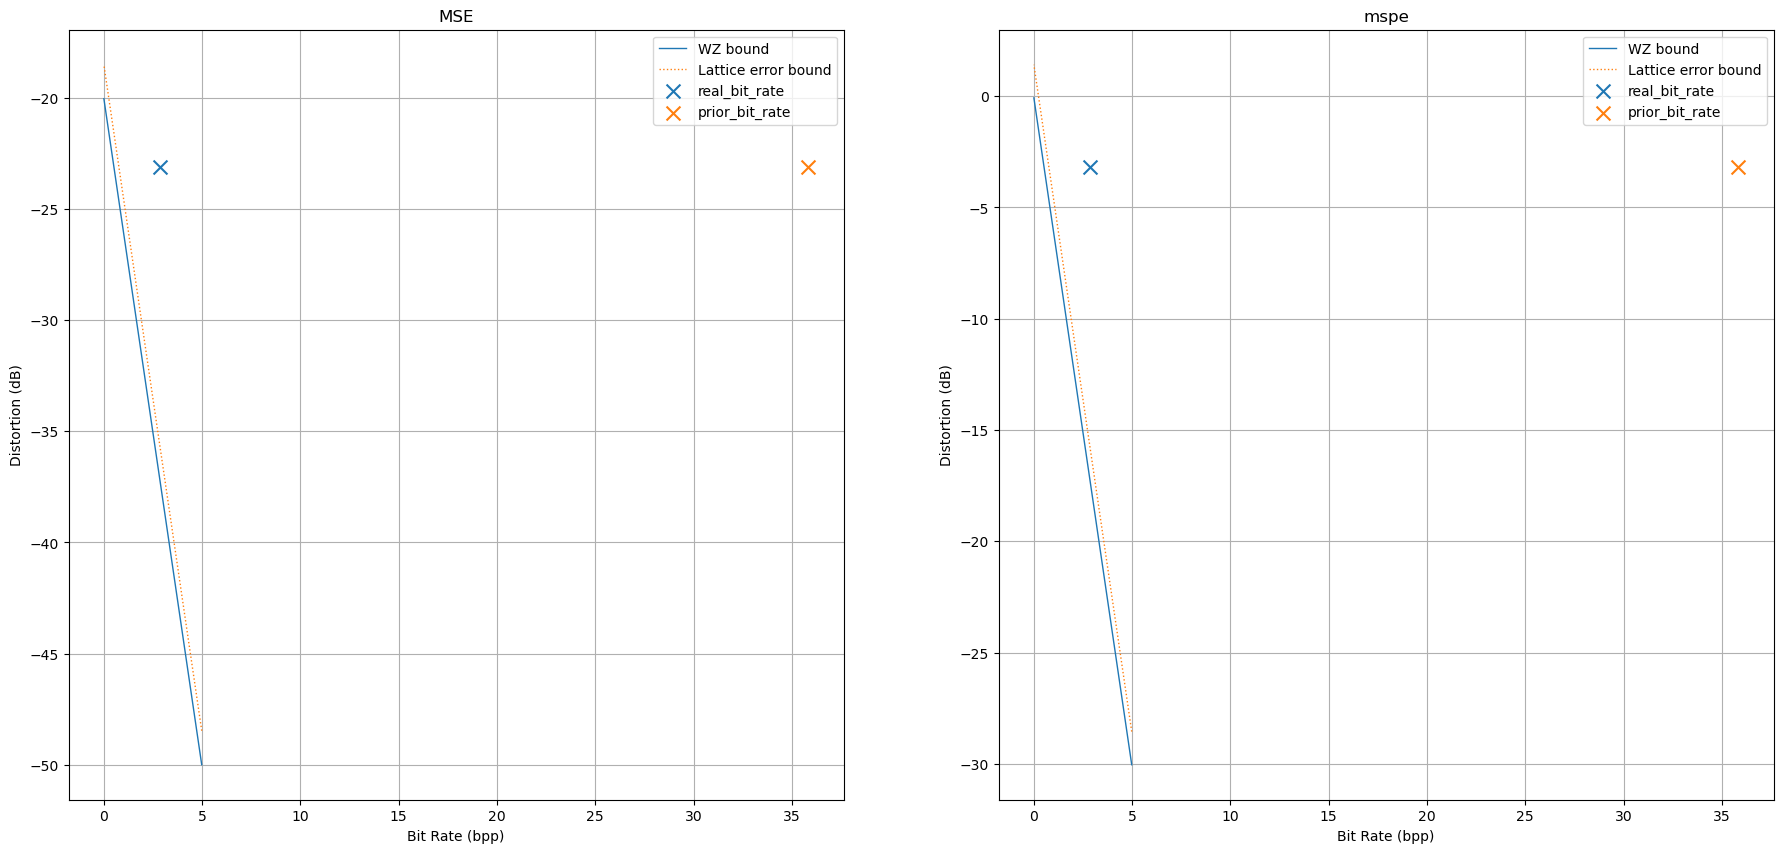

In [16]:
# model_check_path = '../data/basicRNN_3plane_4bins_state.pt'
# model = wz_quantizer.wz_pl_model
# torch.save(model.state_dict(), model_check_path)
# model.load_state_dict(torch.load(model_check_path, map_location='cpu'))

In [23]:
# plt.figure(figsize=(17, 5))
# plt.plot(bins[y_argsort]/(wz_quantizer.bin_count-1))
# plt.plot(y_pred[y_argsort], label='predicted', linewidth=1)
# plt.plot(y[y_argsort], label='true', linewidth=1)

In [24]:
importlib.reload(components.broadcast_components.WZ_models.wz_quant_ANN)
from components.broadcast_components.WZ_models.wz_quant_ANN import plot_bins

temp = np.random.choice(np.arange(len(y)), 100_000, replace=False)
plot_bins(wz_quantizer, y[temp], [a[temp] for a in side_info_data], step_count=10_000)